# Konkan Canara - GRU + U-Net Hybrid Model for Total Precipitation Prediction (4-Step Input Sequence)

In [1]:
# Importing the required libraries
import numpy as np
import joblib
import importlib
    
import random
import gc

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

import KC_Data_Preprocessing as KCD
import Baseline_Model_Definitions as BMD
import Baseline_Model_Utils as BMU
import UNet_Model_Definitions as UMD
import UNet_Model_Utils as UMU

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
torch.cuda.get_device_properties()

_CudaDeviceProperties(name='NVIDIA GeForce RTX 4060 Laptop GPU', major=8, minor=9, total_memory=8187MB, multi_processor_count=24, uuid=a73fa0eb-512f-ffe4-cf94-f2e7b26c980c, pci_bus_id=1, pci_device_id=0, pci_domain_id=0, L2_cache_size=32MB)

In [5]:
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

In [6]:
torch.cuda.init()

In [7]:
gc.collect()
torch.cuda.empty_cache()

## Data Loading and Preprocessing

In [8]:
importlib.reload(KCD);

In [9]:
feature_scaler = joblib.load('feature_scaler_tp.pkl')
target_scaler = joblib.load('target_scaler_tp.pkl')

SEQ_LEN = 4

data = KCD.prepare_konkan_data(
    file_path='KC_6H_2001-2025_Final.csv', 
    feature_scaler=feature_scaler, 
    target_scaler=target_scaler, 
    seq_len=SEQ_LEN, 
    target_variable='tp'
)

X_train, y_train = data['train']
X_val, y_val = data['val']

height = data['meta']['height']
width = data['meta']['width']
num_channels = data['meta']['channels'] 
feature_names = data['meta']['feature_names']

print(f'X_train shape: {X_train.shape} (2001-2018)')
print(f'X_val shape: {X_val.shape} (2019-2020)')

X_train shape: (26292, 4, 32, 12, 8) (2001-2018)
X_val shape: (2924, 4, 32, 12, 8) (2019-2020)


In [10]:
feature_names

['msl', 'sst', 'u10', 'v10', 'ws', 't2m', 'rh', 'tp']

In [11]:
height, width, num_channels

(32, 12, 8)

### Reshaping the data and preparing DataLoaders

In [12]:
# Reshape X_train from (N, SEQ_LEN, 32, 12, 8) to (N, SEQ_LEN, 32 * 12 * 8)
X_train_gru = X_train.reshape(X_train.shape[0], X_train.shape[1], -1) 
y_train_flat = y_train.reshape(y_train.shape[0], -1)

X_val_gru = X_val.reshape(X_val.shape[0], X_val.shape[1], -1)
y_val_flat = y_val.reshape(y_val.shape[0], -1)

print(f'--- GRU Input Shapes ---')
print(f'Train: X={X_train_gru.shape} (Batch, Seq, Features), y={y_train_flat.shape}')
print(f'Val:   X={X_val_gru.shape}, y={y_val_flat.shape}')

--- GRU Input Shapes ---
Train: X=(26292, 4, 3072) (Batch, Seq, Features), y=(26292, 384)
Val:   X=(2924, 4, 3072), y=(2924, 384)


In [13]:
gru_dataset_train = TensorDataset(torch.from_numpy(X_train_gru).float().to(device), 
                                 torch.from_numpy(y_train_flat).float().to(device))
gru_dataset_val = TensorDataset(torch.from_numpy(X_val_gru).float().to(device), 
                               torch.from_numpy(y_val_flat).float().to(device))

BATCH_SIZE_GRU = 128

gru_train_loader = DataLoader(gru_dataset_train, batch_size=BATCH_SIZE_GRU, shuffle=True, pin_memory=False)
gru_val_loader = DataLoader(gru_dataset_val, batch_size=BATCH_SIZE_GRU, shuffle=False, pin_memory=False)

## PyTorch GRU Baseline

In [14]:
importlib.reload(BMD);
importlib.reload(BMU);

In [15]:
INPUT_SIZE_GRU = num_channels * height * width  
HIDDEN_SIZES = [16]
OUTPUT_SIZE_GRU = height * width

gru_model = BMD.GRUModel(
    input_features=INPUT_SIZE_GRU,
    hidden_sizes=HIDDEN_SIZES,
    output_size=OUTPUT_SIZE_GRU
).to(device)

In [16]:
summary(gru_model, input_size=(BATCH_SIZE_GRU, SEQ_LEN, INPUT_SIZE_GRU))

Layer (type:depth-idx)                   Output Shape              Param #
GRUModel                                 [128, 384]                --
├─GRU: 1-1                               [128, 4, 16]              148,320
├─Linear: 1-2                            [128, 384]                6,528
Total params: 154,848
Trainable params: 154,848
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 76.78
Input size (MB): 6.29
Forward/backward pass size (MB): 0.46
Params size (MB): 0.62
Estimated Total Size (MB): 7.37

In [17]:
gru_loss_fn = nn.MSELoss()
gru_optimizer = BMU.lg_optimizer(gru_model)
GRU_EPOCHS = 50

In [18]:
torch.cuda.synchronize()
start_event.record()

train_losses_gru, val_losses_gru = BMU.lg_train_model(
    gru_model, 
    gru_train_loader, 
    gru_val_loader, 
    gru_optimizer,    
    gru_loss_fn,      
    epochs=GRU_EPOCHS,
)

end_event.record()
torch.cuda.synchronize()

Epoch 1/50 | Train Loss: 0.030197 | Val Loss: 0.024282
  --> Saved Best Weights


Epoch 2/50 | Train Loss: 0.017194 | Val Loss: 0.020417
  --> Saved Best Weights


Epoch 3/50 | Train Loss: 0.015890 | Val Loss: 0.019987
  --> Saved Best Weights


Epoch 4/50 | Train Loss: 0.015808 | Val Loss: 0.019956
  --> Saved Best Weights


Epoch 5/50 | Train Loss: 0.015794 | Val Loss: 0.019940
  --> Saved Best Weights


...

Epoch 46/50 | Train Loss: 0.015812 | Val Loss: 0.020012


Epoch 47/50 | Train Loss: 0.015792 | Val Loss: 0.019967


Epoch 48/50 | Train Loss: 0.015797 | Val Loss: 0.020017


Epoch 49/50 | Train Loss: 0.015806 | Val Loss: 0.019937


Epoch 50/50 | Train Loss: 0.015814 | Val Loss: 0.019915


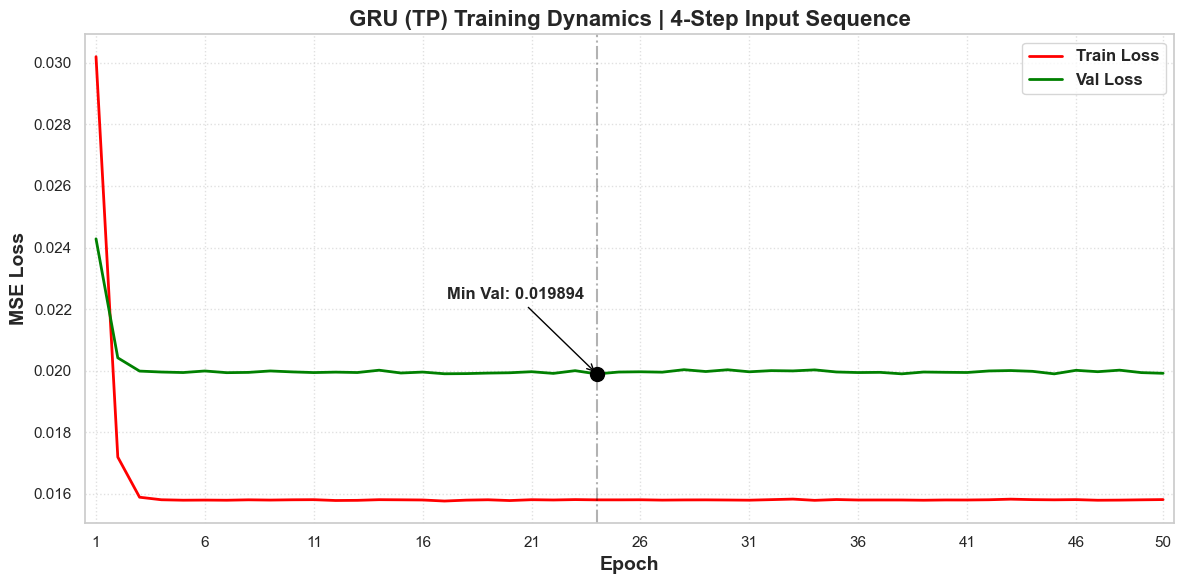

In [19]:
BMU.plot_training_dynamics(
    train_losses_gru, val_losses_gru, loss_name='MSE Loss', model_name='GRU (TP)', seq_len=SEQ_LEN
)

In [20]:
elapsed_time_gru = start_event.elapsed_time(end_event)
gru_duration = elapsed_time_gru / 1000

minutes, seconds = divmod(gru_duration, 60)

if minutes > 0:
    print(f'GRU Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'GRU Training Time: {seconds:.2f} seconds')

GRU Training Time: 47.21 seconds


In [21]:
torch.save(gru_model.state_dict(), 'GRU_4S_TP.pth');

### Generating hints and data loaders for the U-Net models

In [22]:
gru_model.eval()

with torch.inference_mode():
    X_train_gru_tensor = torch.as_tensor(X_train_gru, device=device, dtype=torch.float32)
    X_val_gru_tensor = torch.as_tensor(X_val_gru, device=device, dtype=torch.float32)

    gru_hint_train_flat = gru_model(X_train_gru_tensor)
    gru_hint_val_flat = gru_model(X_val_gru_tensor)

# Reshape hints back to spatial grids
gru_hint_train_tensor = gru_hint_train_flat.view(-1, 1, height, width)
gru_hint_val_tensor = gru_hint_val_flat.view(-1, 1, height, width)

# Get the last timestep (T-1) raw features to concatenate
X_train_last = torch.from_numpy(X_train[:, -1, :, :, :]).float().to(device).permute(0, 3, 1, 2)
X_val_last = torch.from_numpy(X_val[:, -1, :, :, :]).float().to(device).permute(0, 3, 1, 2)

# Concatenating Features + Hint Channel (N, 8+1, 32, 12)
hybrid_X_train_tensor = torch.cat([X_train_last, gru_hint_train_tensor], dim=1)
hybrid_X_val_tensor = torch.cat([X_val_last, gru_hint_val_tensor], dim=1)

y_train_tensor = torch.from_numpy(y_train).float().to(device).permute(0, 3, 1, 2)
y_val_tensor = torch.from_numpy(y_val).float().to(device).permute(0, 3, 1, 2)

print(f'Hybrid Input Shapes: Train={hybrid_X_train_tensor.shape}, Val={hybrid_X_val_tensor.shape}')

Hybrid Input Shapes: Train=torch.Size([26292, 9, 32, 12]), Val=torch.Size([2924, 9, 32, 12])


In [23]:
BATCH_SIZE_UNET = 128

unet_train_loader = DataLoader(
    TensorDataset(hybrid_X_train_tensor, y_train_tensor), 
    batch_size=BATCH_SIZE_UNET, 
    shuffle=True,    
    pin_memory=False
)

unet_val_loader = DataLoader(
    TensorDataset(hybrid_X_val_tensor, y_val_tensor), 
    batch_size=BATCH_SIZE_UNET, 
    shuffle=False,
    pin_memory=False
)

## U-Net Models

In [24]:
importlib.reload(UMU);
importlib.reload(UMD);

In [25]:
unet_loss_fn = torch.nn.GaussianNLLLoss(eps=1e-6, full=True, reduction='none')

In [ ]:
INPUT_CHANNELS_UNET = num_channels + 1
OUTPUT_CHANNELS_UNET = 2
UNET_EPOCHS = 50

### Standard U-Net

In [27]:
hybrid_model1 = UMD.Standard_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model1)

In [28]:
summary(hybrid_model1, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width)) 

Layer (type:depth-idx)                        Output Shape              Param #
Standard_UNet                                 [128, 2, 32, 12]          --
├─BaseDoubleConv: 1-1                         [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                         [128, 64, 32, 12]         --
├─BaseDown: 1-2                               [128, 128, 16, 6]         --
│    └─Sequential: 2-2                        [128, 128, 16, 6]         --
│    │    └─LPPool2d: 3-7                     [128, 64, 16, 6]          --
│    │    └

In [29]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
torch.cuda.synchronize()
start_event.record()

train_losses1, val_losses1, lr_history1 = UMU.train_model(
    hybrid_model1, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: 0.242865 | Val Loss: 0.038905 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.145807 | Val Loss: -0.310848 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -0.510409 | Val Loss: -0.679889 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -0.877057 | Val Loss: -1.018805 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.205582 | Val Loss: -1.262489 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.384557 | Val Loss: -2.296296 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.386468 | Val Loss: -2.296098 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.386071 | Val Loss: -2.295616 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.385317 | Val Loss: -2.295461 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.385551 | Val Loss: -2.296080 | LR: 1.00e-08


In [31]:
elapsed_time_unet1 = start_event.elapsed_time(end_event)
unet_duration1 = elapsed_time_unet1 / 1000

minutes, seconds = divmod(unet_duration1, 60)

if minutes > 0:
    print(f'Standard U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Standard U-Net Training Time: {seconds:.2f} seconds')

Standard U-Net Training Time: 5 minutes and 31.85 seconds


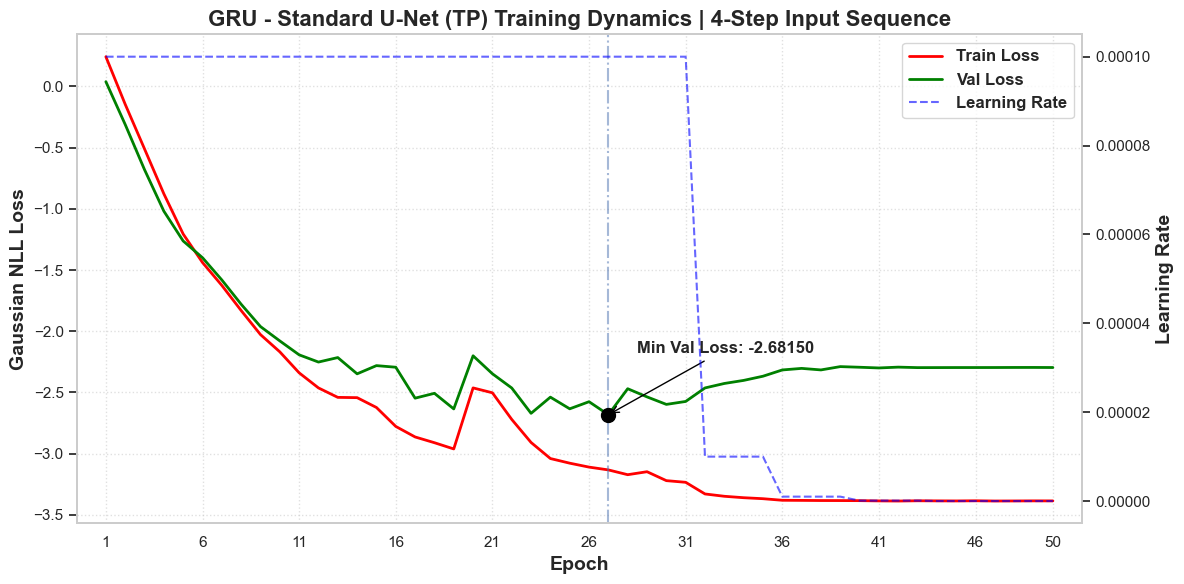

In [32]:
UMU.plot_training_dynamics(train_losses1, val_losses1, lr_history1, 
                       'GRU - Standard U-Net (TP)', SEQ_LEN)

In [33]:
torch.save(hybrid_model1.state_dict(), 'GRU_Standard_U-Net_Hybrid_TP_4S.pth')

In [34]:
del hybrid_model1, 
del optimizer
del scheduler

In [35]:
gc.collect()
torch.cuda.empty_cache()

### Residual U-Net

In [36]:
hybrid_model2 = UMD.Residual_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model2)

In [37]:
summary(hybrid_model2, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                        Output Shape              Param #
Residual_UNet                                 [128, 2, 32, 12]          --
├─ResidualDoubleConv: 1-1                     [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    └─Sequential: 2-2                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-6                       [128, 64, 32, 12]         576
│    │    └─GroupNorm: 3-7                    [128, 64, 32, 12]         128
│    └─ReLU: 2-3                              [128, 64, 32, 12]         --
├─BaseDow

In [38]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
torch.cuda.synchronize()
start_event.record()

train_losses2, val_losses2, lr_history2 = UMU.train_model(
    hybrid_model2, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: -0.816746 | Val Loss: -1.176530 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -1.404188 | Val Loss: -1.370512 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -1.701343 | Val Loss: -1.776045 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.989756 | Val Loss: -1.974242 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -2.203598 | Val Loss: -2.119934 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.464396 | Val Loss: -2.153728 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.462111 | Val Loss: -2.153865 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.463443 | Val Loss: -2.153710 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.463948 | Val Loss: -2.154082 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.462958 | Val Loss: -2.153446 | LR: 1.00e-08


In [40]:
elapsed_time_unet2 = start_event.elapsed_time(end_event)
unet_duration2 = elapsed_time_unet2 / 1000

minutes, seconds = divmod(unet_duration2, 60)

if minutes > 0:
    print(f'Residual U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Residual U-Net Training Time: {seconds:.2f} seconds')

Residual U-Net Training Time: 6 minutes and 24.66 seconds


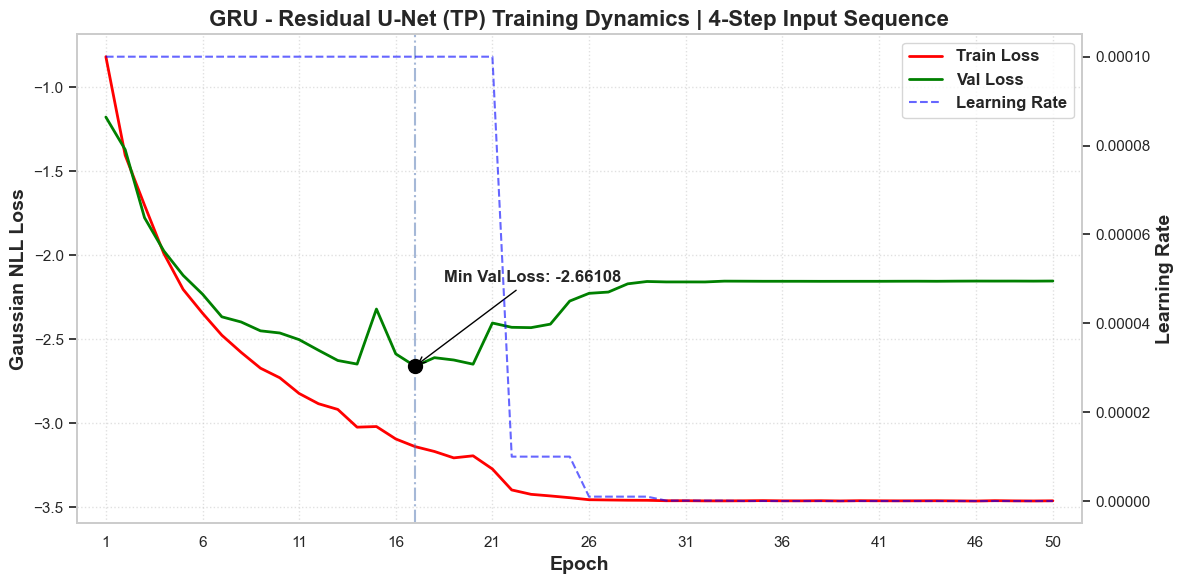

In [41]:
UMU.plot_training_dynamics(train_losses2, val_losses2, lr_history2, 
                       'GRU - Residual U-Net (TP)', SEQ_LEN)

In [42]:
torch.save(hybrid_model2.state_dict(), 'GRU_Residual_U-Net_Hybrid_TP_4S.pth')

In [43]:
del hybrid_model2, 
del optimizer
del scheduler

In [44]:
gc.collect()
torch.cuda.empty_cache()

### Attention U-Net

In [45]:
hybrid_model3 = UMD.Attention_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model3)

In [46]:
summary(hybrid_model3, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                        Output Shape              Param #
Attention_UNet                                [128, 2, 32, 12]          --
├─BaseDoubleConv: 1-1                         [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                         [128, 64, 32, 12]         --
├─BaseDown: 1-2                               [128, 128, 16, 6]         --
│    └─Sequential: 2-2                        [128, 128, 16, 6]         --
│    │    └─LPPool2d: 3-7                     [128, 64, 16, 6]          --
│    │    └

In [47]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
torch.cuda.synchronize()
start_event.record()

train_losses3, val_losses3, lr_history3 = UMU.train_model(
    hybrid_model3, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: -0.108269 | Val Loss: -0.330980 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.529628 | Val Loss: -0.704479 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -0.907759 | Val Loss: -1.049361 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.245227 | Val Loss: -1.305744 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.485845 | Val Loss: -1.360553 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.317637 | Val Loss: -2.328436 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.317761 | Val Loss: -2.328513 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.318180 | Val Loss: -2.328600 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.317453 | Val Loss: -2.328377 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.318202 | Val Loss: -2.328549 | LR: 1.00e-08


In [49]:
elapsed_time_unet3 = start_event.elapsed_time(end_event)
unet_duration3 = elapsed_time_unet3 / 1000

minutes, seconds = divmod(unet_duration3, 60)

if minutes > 0:
    print(f'Attention U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Attention U-Net Training Time: {seconds:.2f} seconds')

Attention U-Net Training Time: 6 minutes and 33.48 seconds


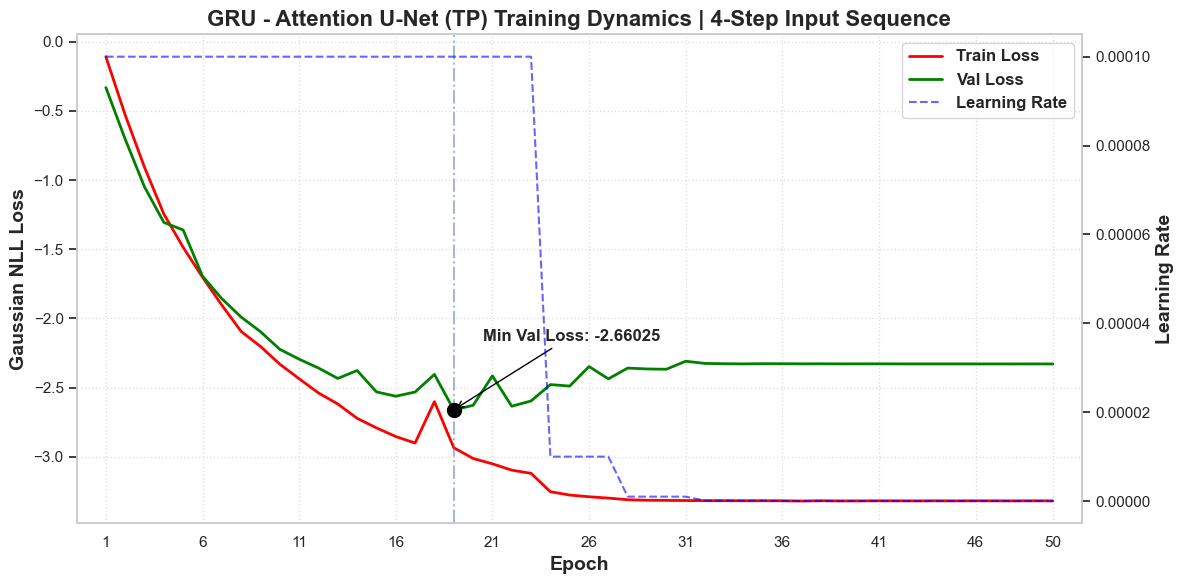

In [50]:
UMU.plot_training_dynamics(train_losses3, val_losses3, lr_history3, 
                       'GRU - Attention U-Net (TP)', SEQ_LEN)

In [51]:
torch.save(hybrid_model3.state_dict(), 'GRU_Attention_U-Net_Hybrid_TP_4S.pth')

In [52]:
del hybrid_model3
del optimizer
del scheduler

In [53]:
gc.collect()
torch.cuda.empty_cache()

### CBAM (Convolution Block Attention Module) U-Net

In [54]:
hybrid_model4 = UMD.CBAM_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model4)

In [55]:
summary(hybrid_model4, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                             Output Shape              Param #
CBAM_UNet                                          [128, 2, 32, 12]          --
├─CBAMDoubleConv: 1-1                              [128, 64, 32, 12]         --
│    └─Sequential: 2-1                             [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                            [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                         [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                              [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                            [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                         [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                              [128, 64, 32, 12]         --
│    └─ChannelAttention: 2-2                       [128, 64, 1, 1]           --
│    │    └─AdaptiveAvgPool2d: 3-7                 [128, 64, 1, 1]           --
│    │    └─Sequential: 3-

In [56]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
torch.cuda.synchronize()
start_event.record()

train_losses4, val_losses4, lr_history4 = UMU.train_model(
    hybrid_model4, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: 0.149267 | Val Loss: -0.092683 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.299388 | Val Loss: -0.485874 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -0.700133 | Val Loss: -0.868900 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.080811 | Val Loss: -1.196353 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.379362 | Val Loss: -1.373730 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.251882 | Val Loss: -2.548156 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.251722 | Val Loss: -2.547920 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.251538 | Val Loss: -2.548036 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.250322 | Val Loss: -2.548064 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.250921 | Val Loss: -2.548282 | LR: 1.00e-08


In [58]:
elapsed_time_unet4 = start_event.elapsed_time(end_event)
unet_duration4 = elapsed_time_unet4 / 1000

minutes, seconds = divmod(unet_duration4, 60)

if minutes > 0:
    print(f'CBAM U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'CBAM U-Net Training Time: {seconds:.2f} seconds')

CBAM U-Net Training Time: 6 minutes and 28.51 seconds


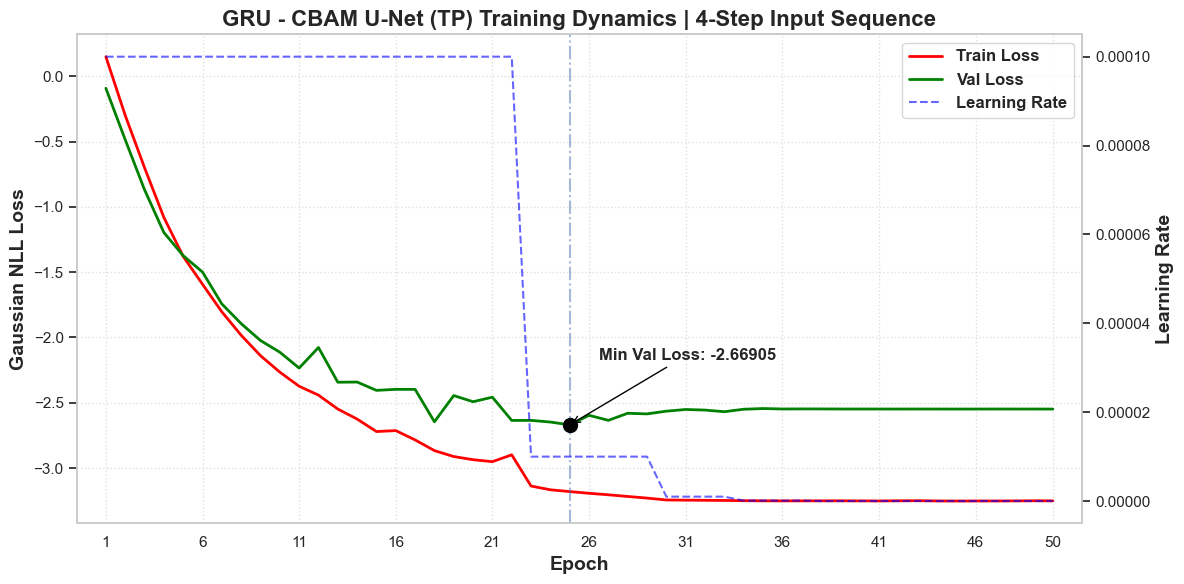

In [59]:
UMU.plot_training_dynamics(train_losses4, val_losses4, lr_history4, 
                       'GRU - CBAM U-Net (TP)', SEQ_LEN)

In [60]:
torch.save(hybrid_model4.state_dict(), 'GRU_CBAM_U-Net_Hybrid_TP_4S.pth')

In [61]:
del hybrid_model4 
del optimizer
del scheduler

In [62]:
gc.collect()
torch.cuda.empty_cache()

## Total Training Time for Each Hybrid Model

In [63]:
total_duration1 = gru_duration + unet_duration1
minutes, seconds = divmod(total_duration1, 60)

if minutes > 0:
    print(f'Total Training Time for GRU - Standard U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for GRU - Standard U-Net: {seconds:.2f} seconds')

Total Training Time for GRU - Standard U-Net: 6 minutes and 19.06 seconds


In [64]:
total_duration2 = gru_duration + unet_duration2
minutes, seconds = divmod(total_duration2, 60)

if minutes > 0:
    print(f'Total Training Time for GRU - Residual U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for GRU - Residual U-Net: {seconds:.2f} seconds')

Total Training Time for GRU - Residual U-Net: 7 minutes and 11.87 seconds


In [65]:
total_duration3 = gru_duration + unet_duration3
minutes, seconds = divmod(total_duration3, 60)

if minutes > 0:
    print(f'Total Training Time for GRU - Attention U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for GRU - Attention U-Net: {seconds:.2f} seconds')

Total Training Time for GRU - Attention U-Net: 7 minutes and 20.69 seconds


In [66]:
total_duration4 = gru_duration + unet_duration4
minutes, seconds = divmod(total_duration4, 60)

if minutes > 0:
    print(f'Total Training Time for GRU - CBAM U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for GRU - CBAM U-Net: {seconds:.2f} seconds')

Total Training Time for GRU - CBAM U-Net: 7 minutes and 15.72 seconds


***